<a href="https://www.kaggle.com/code/rabiatahmed/nlp-detecting-tiktok-claim-videos?scriptVersionId=326207119" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Plan

The goal of this project is to develop a machine learning model for classifying claims made in videos submitted to the platform using the video transcription text as the independent variable. 

TikTok users have the ability to submit reports that identify videos that contain user claims. These reports identify contents that needs to be reviewed by moderators. The process generates a large number of user reports that are challenging to consider in a timely manner. The solution to this, is to develop a predictive model that can determine whether a video contains a claim or offers an opinion. With a successful predictive model, the backlog of user reports can be reduced and prioritized more efficiently.
A "claim" refers to information that is either unsourced or from an unverified source while, an "opinion" refers to an individual's or group's personal belief or thought.

The plan is to implement tree-based models(decision tree, random forest and XGBoost) and then pick a champion model using the F1 score as the deciding metric.

The dataset used for this project contains synthetic data and was gotten from the Google Advanced Data Analytics Certificate Program on Coursera.

In [1]:
# Import packages

import pandas as pd

import re

import seaborn as sns

import matplotlib.pyplot as plt

from wordcloud import WordCloud

import nltk

nltk.download('stopwords') 

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
# Load dataset
df0 = pd.read_csv("/kaggle/input/tiktok-dataset/tiktok_dataset.csv")

# Display first few rows
df0.head(5)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


# **Cleaning and preprocessing the dataset**

In [3]:
# Select columns
df1 = df0[["video_transcription_text", "claim_status"]]

# Display first few rows
df1.head()

,video_transcription_text,claim_status
0,someone shared with me that drone deliveries a...,claim
1,someone shared with me that there are more mic...,claim
2,someone shared with me that american industria...,claim
3,someone shared with me that the metro of st. p...,claim
4,someone shared with me that the number of busi...,claim


In [4]:
# Get number of rows and columns
df1.shape

(19382, 2)

In [5]:
# Check for missing values
df1.isna().sum()

video_transcription_text    298
claim_status                298
dtype: int64

In [6]:
# Drop rows with missing values
df1 = df1.dropna(axis=0)

# Confirm
df1.isna().sum()

video_transcription_text    0
claim_status                0
dtype: int64

In [7]:
# Check for duplicates
df1.duplicated().sum()

72

In [8]:
# Drop duplicates
df1 = df1.drop_duplicates(keep='first')

# Confirm
df1.duplicated().sum()

0

In [9]:
# Check shape after dropping missing values and duplicates
df1.shape

(19012, 2)

In [10]:
# Encode the claim_status variable
df1['claim_status'] = df1['claim_status'].replace({'opinion': 0, 'claim': 1})

# Display first few rows
df1.head()

,video_transcription_text,claim_status
0,someone shared with me that drone deliveries a...,1
1,someone shared with me that there are more mic...,1
2,someone shared with me that american industria...,1
3,someone shared with me that the metro of st. p...,1
4,someone shared with me that the number of busi...,1


In [11]:
# Check the class balance
print(df1["claim_status"].value_counts())

print(df1["claim_status"].value_counts(normalize=True))

claim_status
1    9536
0    9476
Name: count, dtype: int64
claim_status
1    0.501578
0    0.498422
Name: proportion, dtype: float64


There is an approximately 50%-50% split. The data is perfectly balanced

In [12]:
# Remove punctuations

import string
punctuation_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('','', punctuation_list)
    return text.translate(temp)

df1['video_transcription_text'] = df1['video_transcription_text'].apply(lambda x: remove_punctuations(x))
df1.head()

,video_transcription_text,claim_status
0,someone shared with me that drone deliveries a...,1
1,someone shared with me that there are more mic...,1
2,someone shared with me that american industria...,1
3,someone shared with me that the metro of st pe...,1
4,someone shared with me that the number of busi...,1


In [13]:
# Remove stopwords and convert to lowercase

def remove_stopwords(text):
    stop_words = stopwords.words('english')
    imp_words = []
    
    # Storing the important words
    for word in str(text).split():
        word = word.lower()
        if word not in stop_words:
           imp_words.append(word)
    output = " ".join(imp_words)
    return output

df1['video_transcription_text'] = df1['video_transcription_text'].apply(lambda text: remove_stopwords(text))
df1.head()

,video_transcription_text,claim_status
0,someone shared drone deliveries already happen...,1
1,someone shared microorganisms one teaspoon soi...,1
2,someone shared american industrialist andrew c...,1
3,someone shared metro st petersburg average dep...,1
4,someone shared number businesses allowing empl...,1


In [14]:
# Unzip the wordnet.zip file manually

#!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

In [15]:
#from nltk.stem import WordNetLemmatizer
# Create a lemmatizer object
#lemmatizer = WordNetLemmatizer()

# Define a function to lemmatize text
#def lemmatize_text(text):
    # Tokenize the text into words
    #words = nltk.word_tokenize(text)
    
    # Lemmatize each word
    #lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    
    # Join the lemmatized wordsback into a string
    #lemmatized_text = ' '.join(lemmatized_words)
    
    #return lemmatized_text

# Apply the lemmatize_text function to the text column of the dataframe
#df1['video_transcription_text'] = df1['video_transcription_text'].apply(lemmatize_text)
#df1.head()

# Word cloud

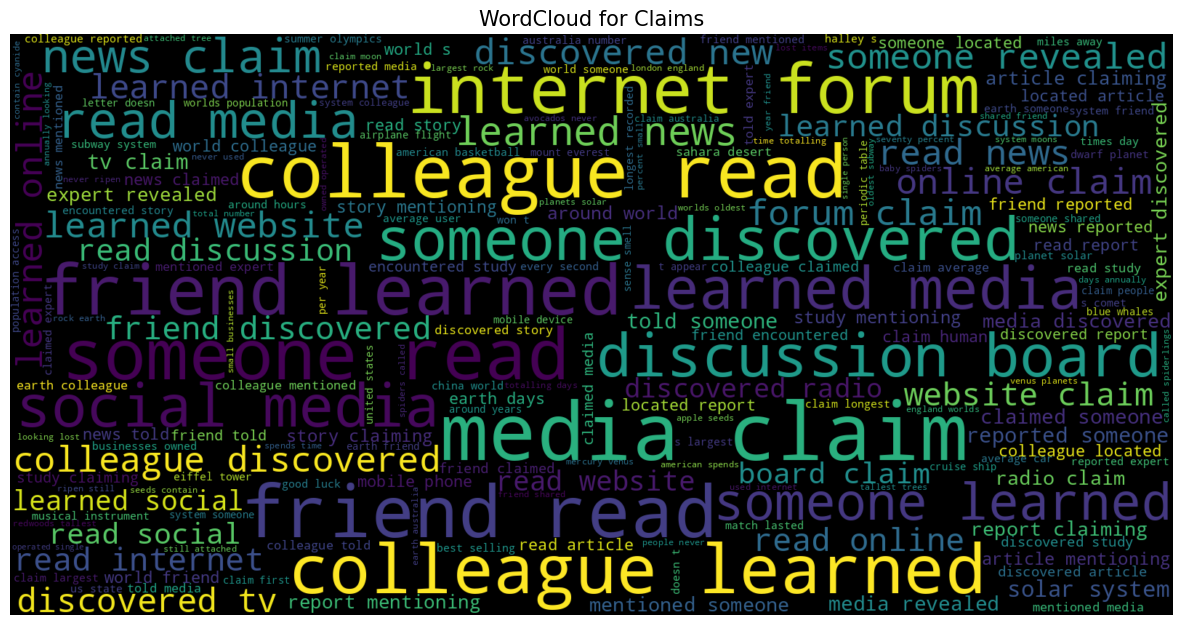

In [16]:
consolidated = ' '.join(word for word in df1['video_transcription_text'][df1['claim_status']==1].astype(str))
wordcloud = WordCloud(width=1600, height=800, random_state=21, max_font_size=110)
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud.generate(consolidated), interpolation = 'bilinear')
plt.title('WordCloud for Claims', fontsize=15)
plt.axis('off')
plt.show()

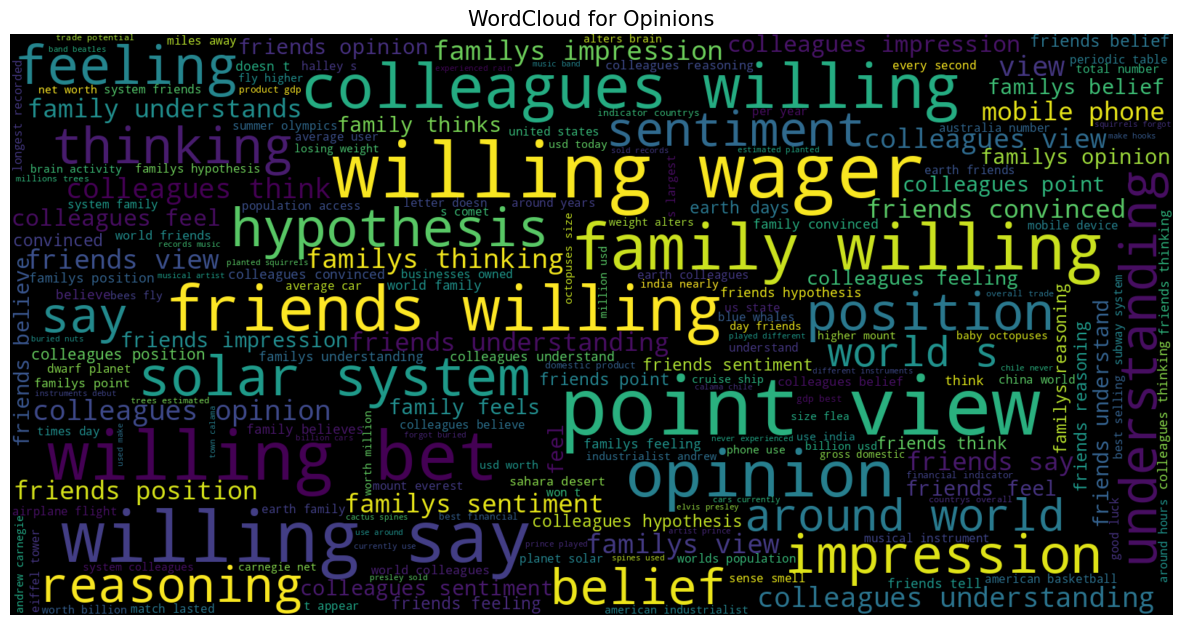

In [17]:
consolidated = ' '.join(word for word in df1['video_transcription_text'][df1['claim_status']==0].astype(str))
wordcloud = WordCloud(width=1600, height=800, random_state=21, max_font_size=110)
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud.generate(consolidated), interpolation = 'bilinear')
plt.title('WordCloud for Opinions', fontsize=15)
plt.axis('off')
plt.show()

**Convert text into vectors**

In [18]:
# Copy dataframe
df_tfidf = df1.copy()

# Display first few rows
df_tfidf.head()

,video_transcription_text,claim_status
0,someone shared drone deliveries already happen...,1
1,someone shared microorganisms one teaspoon soi...,1
2,someone shared american industrialist andrew c...,1
3,someone shared metro st petersburg average dep...,1
4,someone shared number businesses allowing empl...,1


In [19]:
tfidf_vec = TfidfVectorizer(max_features = 2500)

df_tfidf_x = tfidf_vec.fit_transform(df_tfidf['video_transcription_text']).toarray()

In [20]:
df_tfidf_x

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.34397076, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

Split data into training and testing sets, 80/20.

In [21]:
# Split the data into training and testing sets
x_tr, x_test, y_tr, y_test = train_test_split(df_tfidf_x, df_tfidf['claim_status'], test_size = 0.2, random_state = 0)

Split the training set into training and validation sets, 75/25, to result in a final ratio of 60/20/20 for train/validate/test sets.

In [22]:
# Split the training data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_tr, y_tr, test_size=0.25, random_state=0)

Confirm that the dimensions of the training, validation, and testing sets are in alignment.

In [23]:
# Get shape of each training, validation, and testing set
x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape

((11406, 1218), (3803, 1218), (3803, 1218), (11406,), (3803,), (3803,))

# Construct

In [24]:
# This function will extract all the scores from the grid search.

def make_results(model_name, model_object):
    '''
    Accepts as arguments a model name (your choice - string) and a fit GridSearchCV model object.
    
    Returns a pandas df with the accuracy, precision, recall, F1, and AUC scores 
    for the model with the best mean F1 score across all validation folds.
    '''
    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)
    
    # Isolate the row of the df with the max(mean f1 score)
    best_estimator_results = cv_results.iloc[cv_results['mean_test_f1'].idxmax(), :]

    # Extract accuracy, precision, recall, f1, and auc scores from that row
    accuracy = best_estimator_results.mean_test_accuracy
    precision = best_estimator_results.mean_test_precision
    recall = best_estimator_results.mean_test_recall
    f1 = best_estimator_results.mean_test_f1
    auc = best_estimator_results.mean_test_roc_auc

    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                          'Accuracy': [accuracy],
                          'Precision': [precision],
                          'Recall': [recall],
                          'F1': [f1],
                          'AUC': [auc]
                         })
    return table

**Decision tree model**

In [25]:
# Instantiate model
tree = DecisionTreeClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[ None],
             'min_samples_leaf': [5],
             'min_samples_split': [2]
            }

# Assign a dictionary of scoring metrics to capture
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

# Instantiate GridSearch
dt_model = GridSearchCV(tree, cv_params, scoring=scoring, cv=5, refit='f1')

# Fit the model to the training data
dt_model.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [None], 'min_samples_leaf': [5],
                         'min_samples_split': [2]},
             refit='f1',
             scoring={'recall', 'precision', 'roc_auc', 'f1', 'accuracy'})

In [26]:
# Check best F1 score on CV
dt_model.best_score_

0.9988736706296868

This is a strong F1 score

**Random forest model**

In [27]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [5],
             #'max_features': [1.0],
             'max_samples': [0.5],
             'min_samples_leaf': [1],
             'min_samples_split': [2],
             'n_estimators': [200],
             }

# Define a dictionary of scoring metrics to capture
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

# Instantiate the GridSearchCV object
rf_model = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='f1')

# Fit the model to the training data
rf_model.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [5], 'max_samples': [0.5],
                         'min_samples_leaf': [1], 'min_samples_split': [2],
                         'n_estimators': [200]},
             refit='f1',
             scoring={'recall', 'precision', 'roc_auc', 'f1', 'accuracy'})

In [28]:
# Check best F1 score on CV
rf_model.best_score_

1.0

This is a perfect score

**XGBoost model**

In [29]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [12],
             'min_child_weight': [3],
             'learning_rate': [0.01],
             'n_estimators': [500],
             'subsample': [0.7],
             'colsample_bytree': [0.7]
             }

# Define a dictionary of scoring metrics to capture
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

# Instantiate the GridSearchCV object
xgb_model = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='f1')

#Fit the model to the training data
xgb_model.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=0, ...),
             param_grid={'colsample_bytree': [0.7], 'learning_rate': [0.01],
                         'max_depth': [12], 'min_child_weight': [3],
                         'n_estimators': [500], 'subsample': [0.7]},
             refit='f1',
             scoring={'recall', 'precision', 'roc_auc', 'f1', 'accuracy'})

In [30]:
# Check best F1 score on CV
xgb_model.best_score_

0.9980915562161329

This is also a strong score

In [31]:
# Get all CV scores for the models 
dt_results = make_results('Decision tree', dt_model)
rf_results = make_results('Random forest', rf_model) 
xgb_results = make_results('XGBoost', xgb_model)

In [32]:
# Print all training scores
print(dt_results)
print(rf_results)
print(xgb_results)

           Model  Accuracy  Precision    Recall        F1       AUC
0  Decision tree   0.99886   0.999654  0.998096  0.998874  0.999298
           Model  Accuracy  Precision  Recall   F1  AUC
0  Random forest       1.0        1.0     1.0  1.0  1.0
     Model  Accuracy  Precision    Recall        F1       AUC
0  XGBoost  0.998071        1.0  0.996192  0.998092  0.999952


All of these evaluation scores from the models are strong indicators of good model performance.

**Evaluate models**

In [33]:
# This function will extract all the scores from a model’s predictions.

def get_scores(model_name:str, model, x_test_data, y_test_data):
    '''
    Generate a table of validation and test scores.
    In:
    model_name (string): How you want your model to be named in the output table
    model: A fit GridSearchCV object
    x_test_data: numpy array of x_test data
    y_test_data: numpy array of y_test data
    Out: pandas df of  accuracy, precision, recall, F1, and AUC scores for your model
    '''
    preds = model.best_estimator_.predict(x_test_data)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)
    auc = roc_auc_score(y_test_data, preds)
    
    table = pd.DataFrame({'Model': [model_name],
                          'Accuracy': [accuracy],
                          'Precision': [precision],
                          'Recall': [recall],
                          'F1': [f1],
                          'AUC': [auc]
                        })
    return table

**Predict the models on the validation set.**

In [34]:
# Get predictions on validation data for the three models
dt_val_scores = get_scores('Decision tree val scores', dt_model, x_val, y_val)
rf_val_scores = get_scores('Random forest val scores', rf_model, x_val, y_val)
xgb_val_scores = get_scores('xgboost val scores', xgb_model, x_val, y_val)

In [35]:
# Print all validation scores
print(dt_val_scores)
print(rf_val_scores)
print(xgb_val_scores)

                      Model  Accuracy  Precision    Recall        F1       AUC
0  Decision tree val scores  0.998948   0.999462  0.998389  0.998925  0.998937
                      Model  Accuracy  Precision  Recall        F1       AUC
0  Random forest val scores  0.999737   0.999463     1.0  0.999732  0.999742
                Model  Accuracy  Precision    Recall        F1       AUC
0  xgboost val scores  0.997896        1.0  0.995704  0.997847  0.997852


The models achieved nearly perfect validation scores. However, the random forest model performed a little bit better using the F1 score as the deciding metric, so it is the champion model.

**Use the champion model to predict on the test data.**

In [36]:
# Predict champion model on test data
rf_test_scores = get_scores('Random forest test scores', rf_model, x_test, y_test)
rf_test_scores

,Model,Accuracy,Precision,Recall,F1,AUC
0,Random forest test scores,1.0,1.0,1.0,1.0,1.0


Perfect scores!

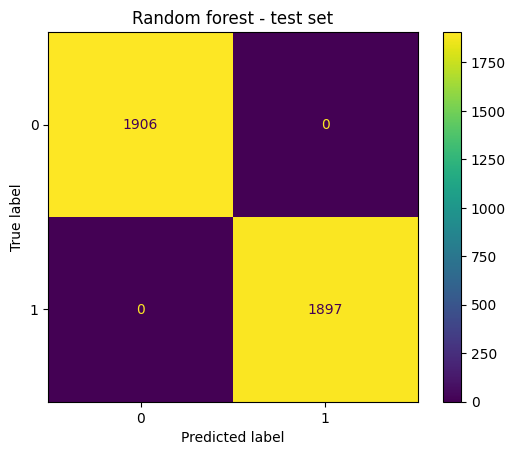

In [37]:
# Generate array of values for confusion matrix
preds = rf_model.best_estimator_.predict(x_test)
cm = confusion_matrix(y_test, preds, labels=rf_model.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)

disp.plot(values_format='');
plt.title('Random forest - test set');

No misclassification-0 false positive and 0 false negative. This appears to be a perfect final model

# Execute

**Summary of results**

The random forest model achieved 100% on all the metric scores when evaluated on the test data. The model slightly outperformed the decision tree model and XGBoost model using the F1 score as the deciding metric.